## Problem 3A

In [ ]:
import pandas as pd
import numpy as np
from scipy.linalg import solve
from datetime import datetime
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

In [ ]:
# Read CSV file
movies = pd.read_csv("movies.csv")

# Shuffle the DataFrame
np.random.seed(0)
movies = movies.sample(frac=1).reset_index(drop=True)

# remove movies with budget = 0 and movies whose runtime is not available
movies = movies[movies['budget'] > 0]
movies = movies.dropna(subset=['runtime'])

movies['age'] = (datetime.strptime("01/01/2024", "%m/%d/%Y") - pd.to_datetime(movies['release_date'])).dt.days
movies['title_len'] = movies['title'].apply(len)
movies["log_budget"] = np.log(movies["budget"])
movies["big_budget"] = (movies["budget"] > movies["budget"].quantile(0.75)).astype(int)

# Select features
features = ["big_budget", "Action", "Drama", "Comedy", "Horror", "log_budget", "runtime", "age", "title_len"]
Y = movies['revenue'].values / 1000000
X = movies[features].values 


# Add a column of ones to X
n = len(X)
p = X.shape[1]
X = np.hstack((X, np.ones((n, 1))))


# Split data into learning and test sets
n_test = 2000
n_learn = 1000
Y_test = Y[:n_test]
Y_learn = Y[n_test:n_test+n_learn]
X_test = X[:n_test, :]
X_learn = X[n_test:n_test+n_learn, :]

K = 10
folds = np.array_split(range(n_learn), K)

validerr = np.zeros((K, 2))

for k in range(K):
    valid_ix = folds[k]
    train_ix = np.setdiff1d(range(n_learn), folds[k])

    X_valid = X_learn[valid_ix, :]
    X_train = X_learn[train_ix, :]

    Y_valid = Y_learn[valid_ix]
    Y_train = Y_learn[train_ix]

    # Fit two separate linear regression models
    idx = X_train[:, 0] == 1  # Assuming first column is "big_budget" indicator

    X_train1 = X_train[idx, 1:]
    X_train2 = X_train[~idx, 1:]

    ## FILL IN
    Y_train1 = Y_train[idx]
    Y_train2 = Y_train[~idx]

    beta1 = np.linalg.solve(X_train1.T @ X_train1, X_train1.T @ Y_train1)
    beta2 = np.linalg.solve(X_train2.T @ X_train2, X_train2.T @ Y_train2)

    idx_valid = X_valid[:, 0] == 1

    X_valid1 = X_valid[idx_valid, 1:]
    X_valid2 = X_valid[~idx_valid, 1:]

    Y_pred = np.zeros(len(Y_valid))

    Y_pred[idx_valid] = X_valid1 @ beta1
    Y_pred[~idx_valid] = X_valid2 @ beta2

    validerr[k, 0] = np.mean((Y_pred - Y_valid) ** 2)

    # Fit one linear regression model on all the data
    beta_all = np.linalg.solve(X_train.T @ X_train, X_train.T @ Y_train)
    Y_pred2 = X_valid @ beta_all

    validerr[k, 1] = np.mean((Y_pred2 - Y_valid) ** 2)

mean_validerr = validerr.mean(axis=0)

print(f"Mean validation error for separated models: {mean_validerr[0]:.3f}")
print(f"Mean validation error for combined model: {mean_validerr[1]:.3f}")
print("")


<ipython-input-2-7d6aa4fe6d67>:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  movies['age'] = (datetime.strptime("01/01/2024", "%m/%d/%Y") - pd.to_datetime(movies['release_date'])).dt.days


Mean validation error for separated models: 14868.707
Mean validation error for combined model: 19587.259



## Problem 3B

In [ ]:
## Fit final model

if (mean_validerr[0] < mean_validerr[1]):
    
    print("Final model: separated models")

    idx = X_learn[:, 0] == 1

    X_train1 = X_learn[idx, 1:]
    X_train2 = X_learn[~idx, 1:]
    Y_train1 = Y_learn[idx]
    Y_train2 = Y_learn[~idx]

    beta1 = np.linalg.solve(X_train1.T @ X_train1, X_train1.T @ Y_train1)
    beta2 = np.linalg.solve(X_train2.T @ X_train2, X_train2.T @ Y_train2)

    idx_test = X_test[:, 0] == 1
    X_test1 = X_test[idx_test, 1:]
    X_test2 = X_test[~idx_test, 1:]
    Y_pred = np.zeros(len(Y_test))

    Y_pred[idx_test] = X_test1 @ beta1
    Y_pred[~idx_test] = X_test2 @ beta2

else:
    print("Final model: combined model")

    beta_all = np.linalg.solve(X_learn.T @ X_learn, X_learn.T @ Y_learn)

    Y_pred = X_test @ beta_all

testerr = np.mean((Y_pred - Y_test) ** 2)
baseline_err = np.mean((Y_test - np.mean(Y_learn)) ** 2)

print(f"Test Error: {testerr:.3f}   Baseline: {baseline_err:.3f}")

err = Y_pred - Y_test
ix = np.argsort(err)
print("\nMovies where we most over-predicted")
for i in range(10):
    j = ix[-i-1]
    print(f"{movies.iloc[j]['title']}.  predicted: {Y_pred[j]:.1f}  actual: {Y_test[j]:.1f}")

print("\nMovies where we most under-predicted")
for i in range(10):
    j = ix[i]
    print(f"{movies.iloc[j]['title']}.  predicted: {Y_pred[j]:.1f}  actual: {Y_test[j]:.1f}")

ix = np.argsort(abs(err))
print("\nMovies with smallest absolute prediction error")
for i in range(10):
    j = ix[i]
    print(f"{movies.iloc[j]['title']}.  predicted: {Y_pred[j]:.1f}  actual: {Y_test[j]:.1f}")

Final model: separated models
Test Error: 15582.670   Baseline: 32017.765

Movies where we most over-predicted
Watchmen.  predicted: 540.3  actual: 185.3
Gods of Egypt.  predicted: 498.7  actual: 150.7
Gods and Generals.  predicted: 356.2  actual: 12.9
Alexander.  predicted: 510.2  actual: 167.3
Around the World in 80 Days.  predicted: 404.9  actual: 72.2
The Chronicles of Narnia: Prince Caspian.  predicted: 750.0  actual: 419.7
Stealth.  predicted: 393.9  actual: 76.9
Pan.  predicted: 440.9  actual: 128.4
Green Lantern.  predicted: 529.5  actual: 219.9
Final Fantasy: The Spirits Within.  predicted: 392.3  actual: 85.1

Movies where we most under-predicted
Avatar.  predicted: 718.1  actual: 2788.0
Jurassic World.  predicted: 495.0  actual: 1513.5
Furious 7.  predicted: 597.5  actual: 1506.2
The Lion King.  predicted: 39.6  actual: 788.2
Despicable Me 2.  predicted: 243.7  actual: 970.8
Finding Nemo.  predicted: 230.4  actual: 940.3
Star Wars.  predicted: 98.9  actual: 775.4
The Secret 

# Problem 4


In [ ]:

np.random.seed(2)

# Load data
shaq = pd.read_csv("shaq.csv")
n = len(shaq)
shaq = shaq.sample(frac=1).reset_index(drop=True)

# Part (a)
# 1. Compute and display the average accuracy of Shaq's free throw

print("Average accuracy:", shaq["shot_made"].mean())

# 2. Compute and display the average accuracy of Shaq's free throw during a home game

print("Average accuracy during home games:", shaq.loc[shaq["home_game"] == 1, "shot_made"].mean())

# 3. Compute and display the average accuracy of Shaq's free throw when the free throw is the first of the two free throws.

print("Average accuracy on first shots:", shaq.loc[shaq["first_shot"] == 1, "shot_made"].mean())


Average accuracy: 0.522671568627451
Average accuracy during home games: 0.5494327390599676
Average accuracy on first shots: 0.48577680525164113


In [ ]:
# Part (b)
features = ["first_shot", "missed_first", "home_game", "cur_score",
            "opp_score", "cur_time", "score_ratio",
            "made_first", "losing"]

X = shaq[features]
Y = shaq["shot_made"].values

n_learn = round(n * 0.8)
n_test = n - n_learn

X_learn, X_test = X.iloc[:n_learn, :], X.iloc[n_learn:(n_learn+n_test), :]
Y_learn, Y_test = Y[:n_learn], Y[n_learn:(n_learn+n_test)]

Y_learn = Y_learn.reshape(-1, 1)
Y_test = Y_test.reshape(-1, 1)

# Define columns to standardize
cols_to_scale = ["cur_score","opp_score", "cur_time", "score_ratio"]
mean_l = X_learn[cols_to_scale].mean(axis=0)
sd_l = X_learn[cols_to_scale].std(axis=0)

Xs = X_learn.copy()
Xs[cols_to_scale] = (Xs[cols_to_scale] - mean_l)/sd_l

# Standardize X_test appropriately
Xs_test = X_test.copy()
Xs_test[cols_to_scale] = (Xs_test[cols_to_scale] - mean_l)/sd_l

In [ ]:
#K=5
#logisticCV = LogisticRegressionCV(Cs=100, l1_ratios=[1.0], cv=K)

# Fit the model
# FILL IN
#logisticCV.fit(Xs, Y_learn.ravel())

K=5
logisticCV = LogisticRegressionCV(
    Cs=100,
    cv=K,
    penalty="l1",
    solver="saga",
    max_iter=10000
)

# Fit the model
logisticCV.fit(Xs, Y_learn.ravel())

,Cs,100
,fit_intercept,True
,cv,5
,dual,False
,penalty,'l1'
,scoring,None
,solver,'saga'
,tol,0.0001
,max_iter,10000
,class_weight,None
,n_jobs,None


In [ ]:
# Prediction
Y_pred = logisticCV.predict(Xs_test)
test_err = np.mean(Y_test != Y_pred.squeeze())

In [ ]:
# Baseline error
baseline_pred = logisticCV.predict(Xs_test)
baseline_err = np.mean(Y_test.squeeze() != baseline_pred)

print(f"LR error: {test_err:.4f}   Baseline error: {baseline_err:.4f}")

LR error: 0.4962   Baseline error: 0.4571


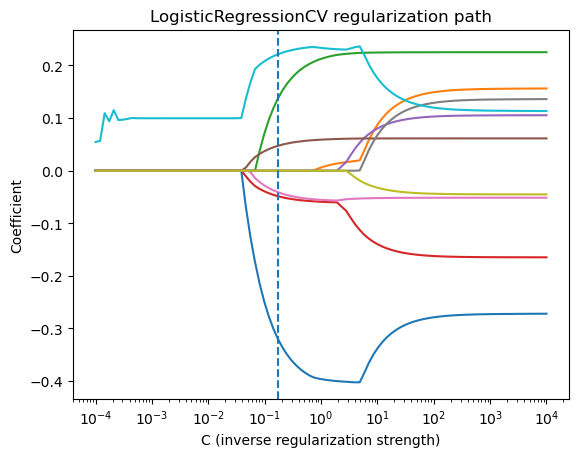

In [ ]:
cls = logisticCV.classes_[1]
Cs = logisticCV.Cs_ 
paths = logisticCV.coefs_paths_[cls]
coef_paths = paths[0].reshape(len(Cs), -1)

plt.figure()
plt.semilogx(Cs, coef_paths)     # one line per feature
plt.axvline(logisticCV.C_[0], linestyle="--")  # chosen C after CV
plt.xlabel("C (inverse regularization strength)")
plt.ylabel("Coefficient")
plt.title("LogisticRegressionCV regularization path")
plt.show()